In [2]:
using Pkg
Pkg.activate("/Users/alia/Desktop/envs/ants")
using BifurcationKit
using Plots
using DifferentialEquations
using LaTeXStrings
using JLD2
using CSV
using DataFrames

  Activating project at `~/Desktop/envs/ants`


In [25]:
function model_4d(x,p)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,
    n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau,gamma)=p
    S,B,C,T = x
    H = 1 - S - B - C - T
    Sdot = (-(alphaC+alphaB+alphaT)*S) + gamma*H
    Cdot = alphaC*S - omegaC*C/(1+ (C/k)^n)
    Bdot = alphaB*S - omegaB*B/(1+ (C/k)^n)
    Tdot = alphaT*S - beta*T

    [
        Sdot
        Bdot
        Cdot
        Tdot
    ]
end

model_4d (generic function with 1 method)

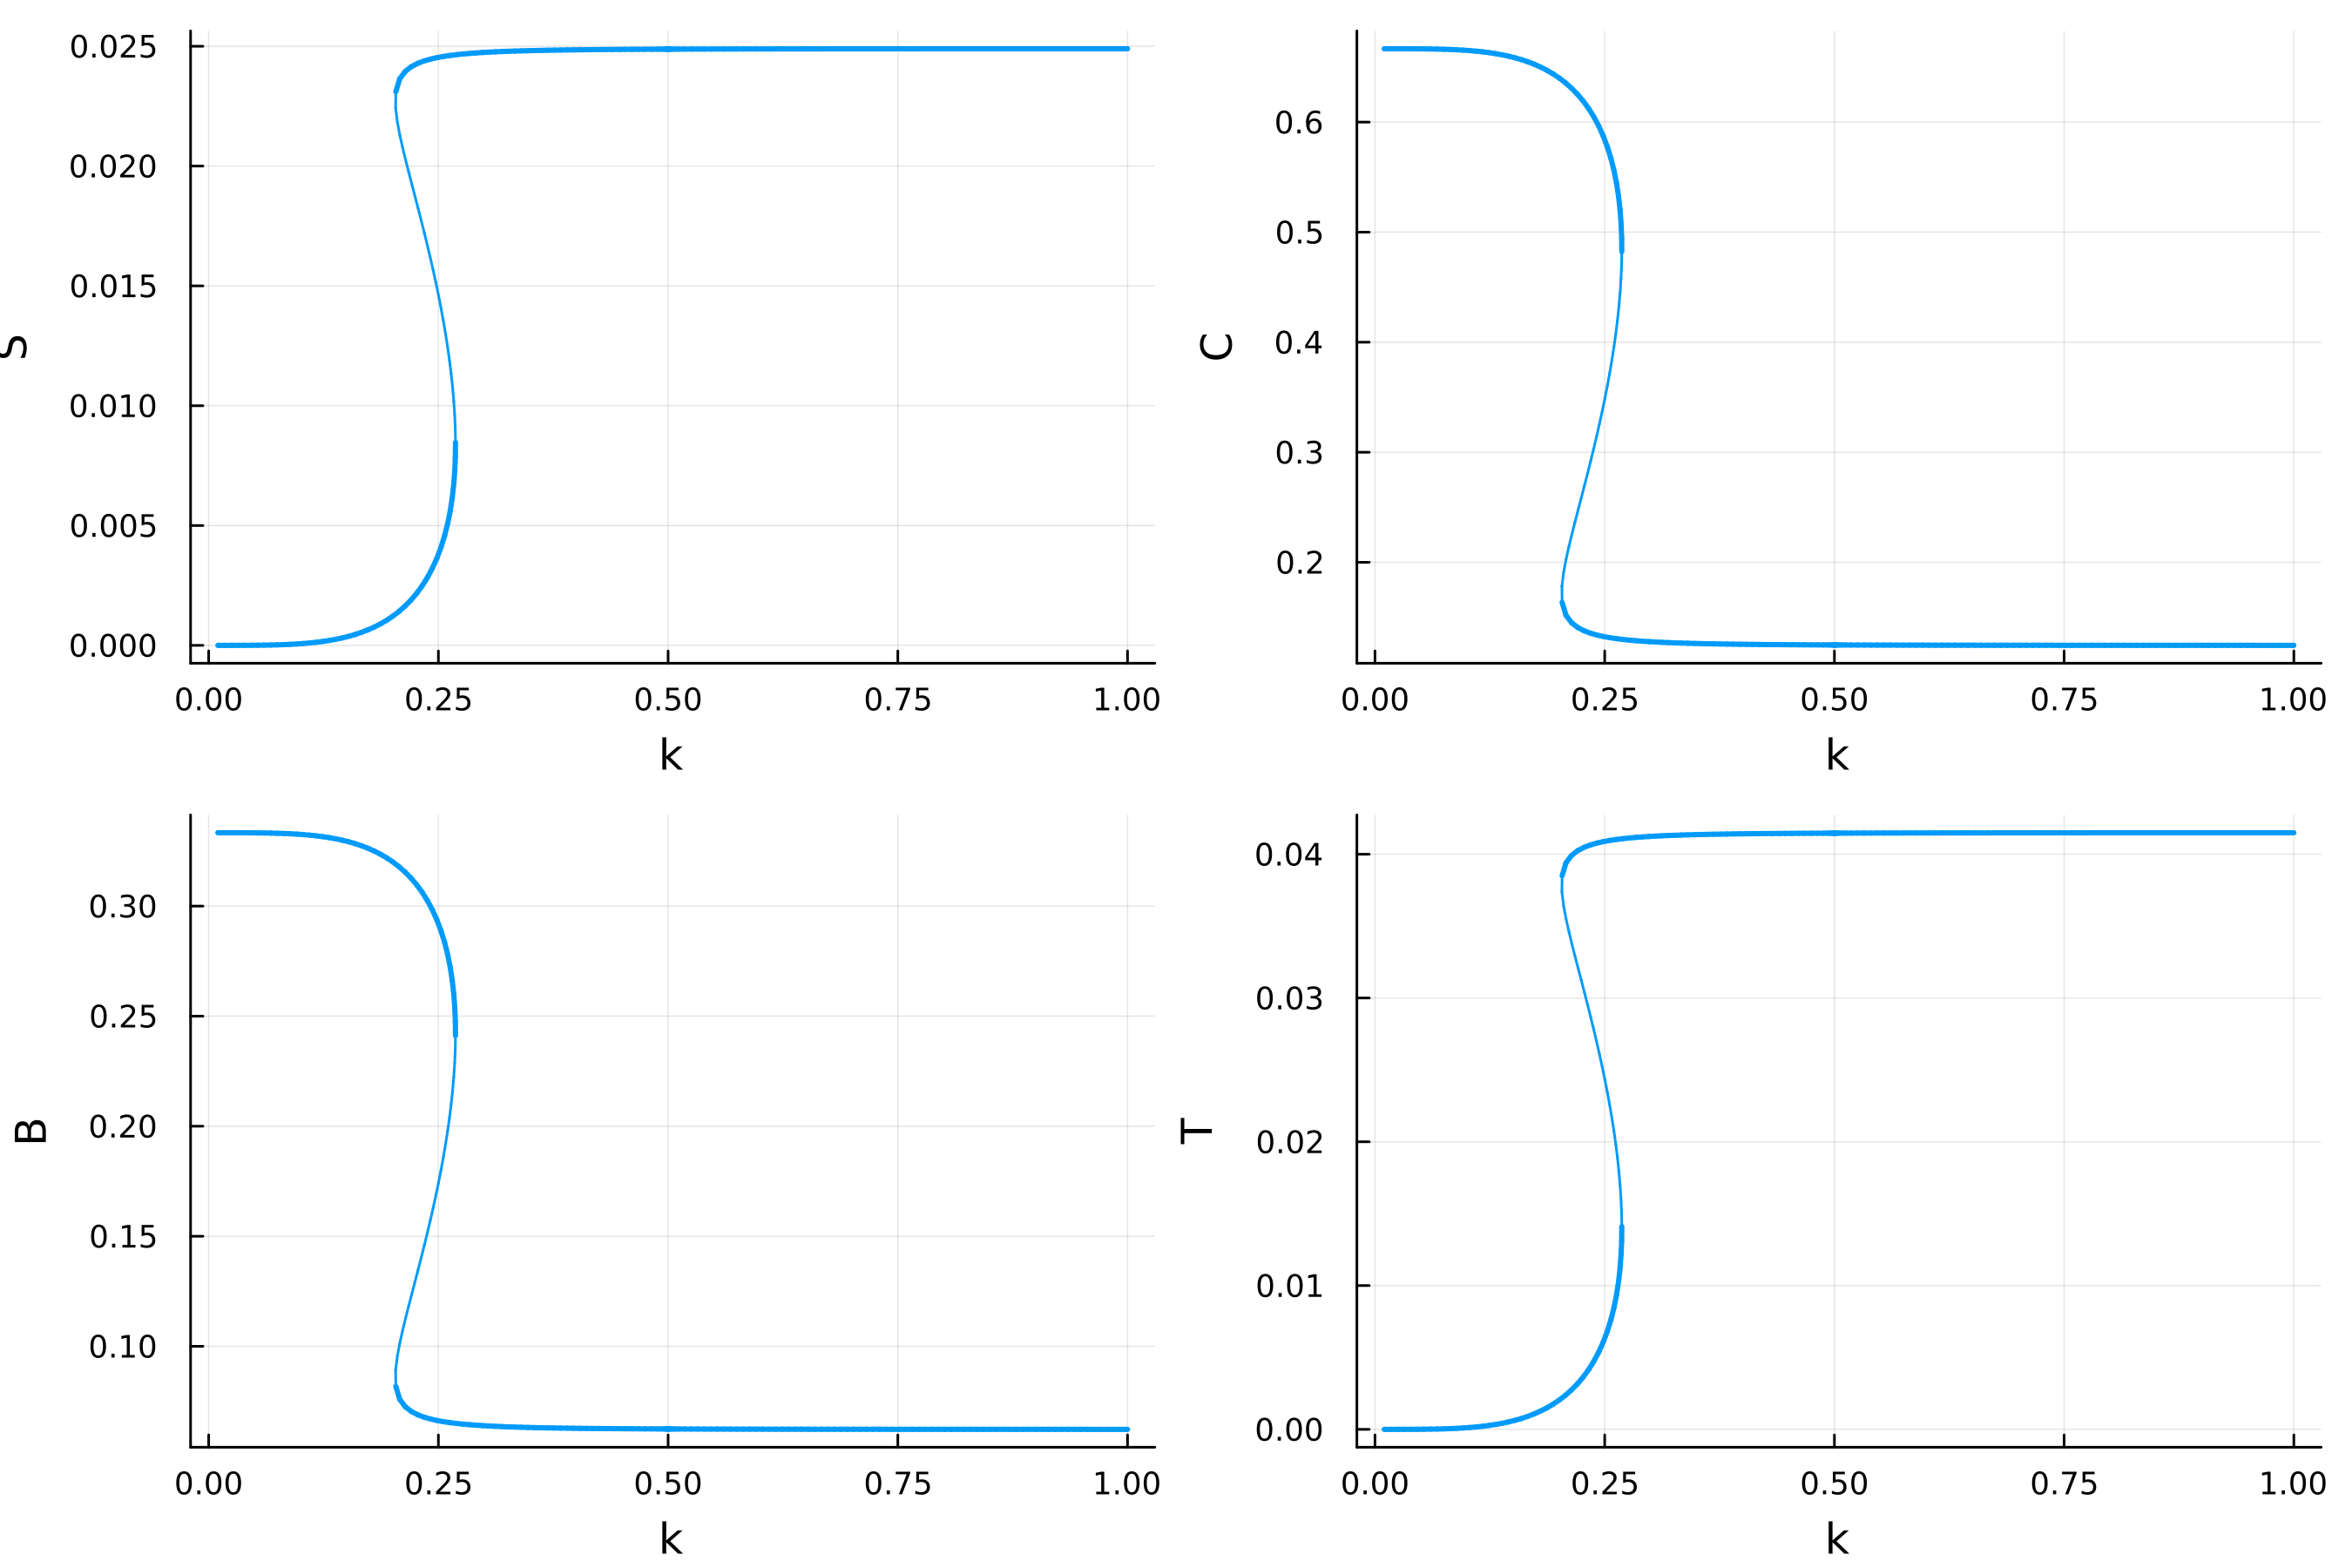

In [119]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
     k=0.5,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
     aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau = par
u0 = [0.5,0.0,0.0,0.0]

u_bif_problem = BifurcationProblem(model_4d, u0, par, (@optic _.k),
               record_from_solution = (x, p; k...) -> (S = x[1], B = x[2], C = x[3], T = x[4]))

opts_br = ContinuationPar(
    p_min = 0.01, p_max = 1.0,
    ds = 1e-5,
    dsmax = 5e-3,
    dsmin = 1e-6,
    detect_bifurcation = 1,
    n_inversion = 8,

    newton_options = NewtonPar(
        tol = 1e-8,
        max_iterations = 100,
        verbose = false
    ),
    tol_stability = 1e-8,
)

u_branch_equilibria = continuation(u_bif_problem, PALC(),opts_br,bothside=true)

p1=plot(u_branch_equilibria,vars = (:param,:S))
p2 =plot(u_branch_equilibria,vars = (:param,:C))
p3=plot(u_branch_equilibria,vars = (:param,:B))
p4= plot(u_branch_equilibria,vars = (:param,:T))
FIG = plot(p1,p2,p3,p4, layout = 4,size = (900,600),dpi=300)

In [ ]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
     k=0.5,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
     aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1) # these params give hysteresis in k, bif is around 0.25

In [122]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.2,omegaB=0.4,
     k=0.5,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,
     aCB=-0.2,aTB=0.2,bB=-0.5,aCT=-0.2,aBT=0.2,bT=0.5,tau = 3,gamma = 0.1)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT,tau = par
u0 = [0.5,0.0,0.0,0.0]


u_bif_problem = BifurcationProblem(model_4d, u0, par, (@optic _.k),
               record_from_solution = (x, p; k...) -> (S = x[1], B = x[2], C = x[3], T = x[4]))

opts_br = ContinuationPar(
    p_min = 0.01, p_max = 1.0,
    ds = 1e-5,
    dsmax = 5e-3,
    dsmin = 1e-6,
    detect_bifurcation = 1,
    n_inversion = 8,

    newton_options = NewtonPar(
        tol = 1e-8,
        max_iterations = 100,
        verbose = false
    ),
    tol_stability = 1e-8,
)

# automatic bifurcation diagram computation
diagram = bifurcationdiagram(u_bif_problem,PALC(),
	4,
	opts_br,bothside = true
	)

[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Children number: 0
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 215
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter k starts at 0.01, ends at 1.0
      ├─ Algo: PALC [Secant]
      └─ Special points:

- #  1, endpoint at k ≈ +0.01000000,                                                                     step =   0
- #  2,     fold at k ≈ +0.26784714 ∈ (+0.26860945, +0.26860945), |δp|=-1e+00, [    guess], δ = ( 0,  0), step =  44
- #  3,     fold at k ≈ +0.20796442 ∈ (+0.20342264, +0.20342264), |δp|=-1e+00, [    guess], δ = ( 0,  0), step =  70
- #  4, endpoint at k ≈ +1.00000000,                                                                     step = 214


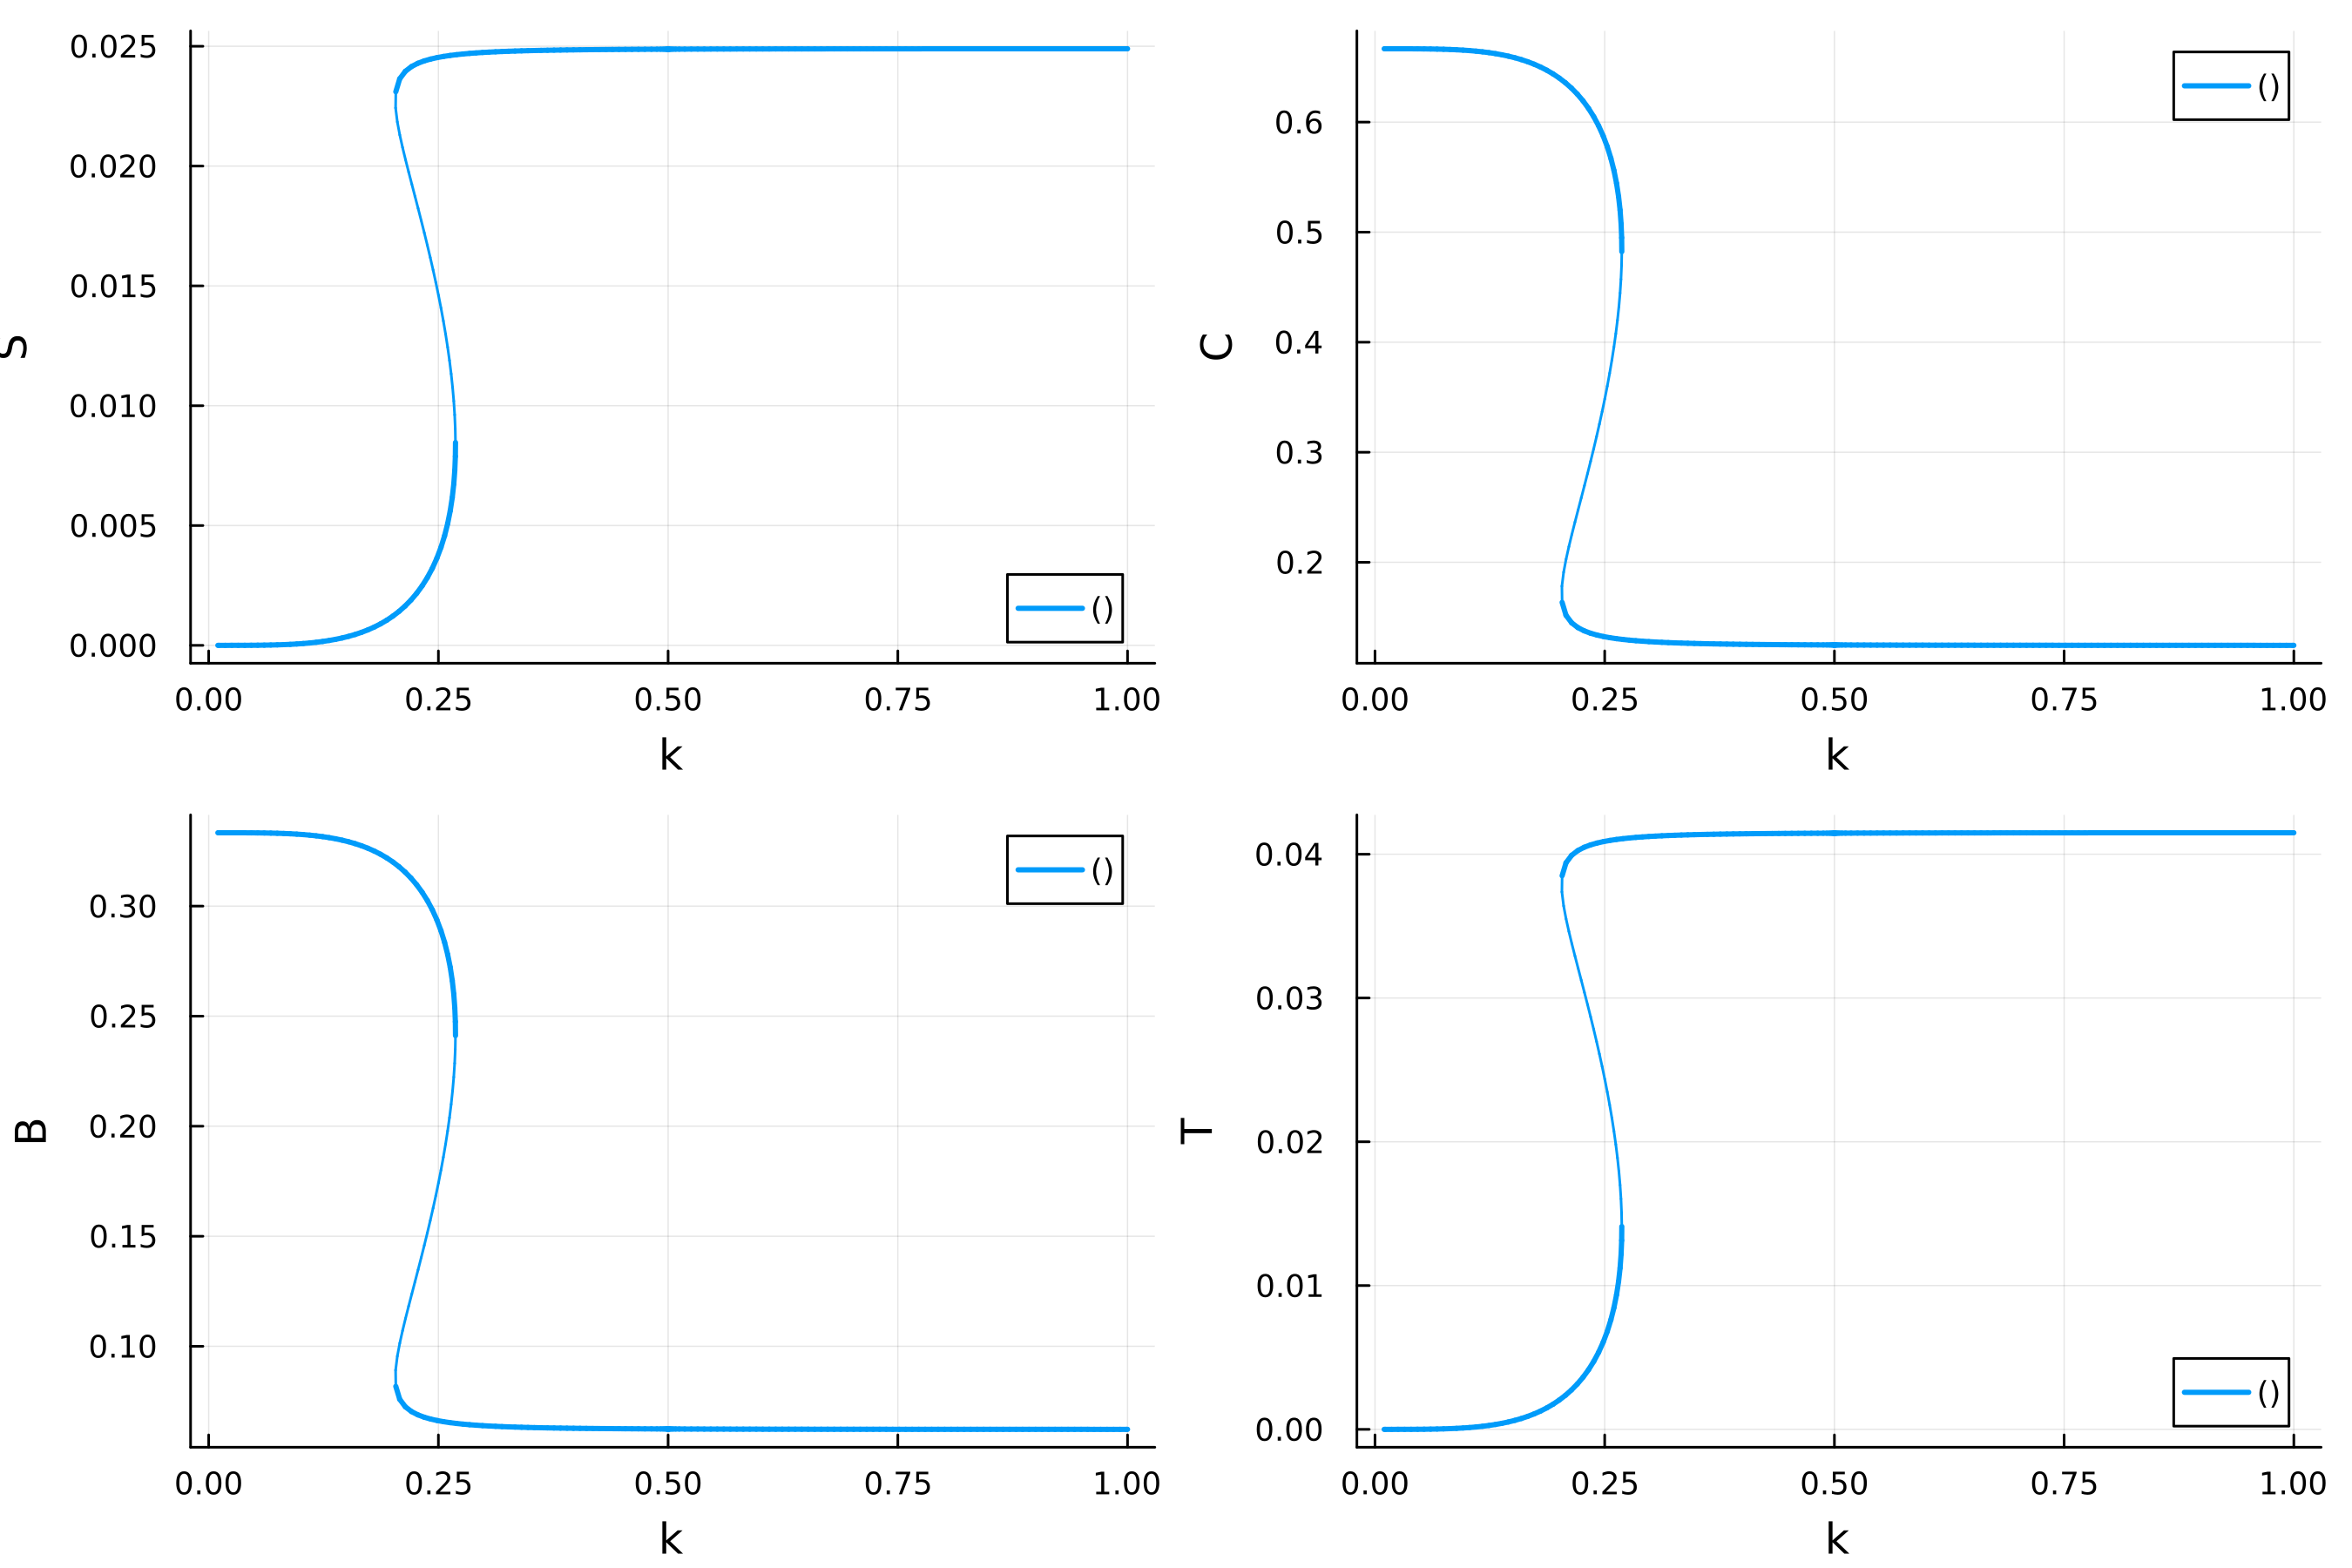

In [123]:
p1=plot(diagram,vars = (:param,:S))
p2 =plot(diagram,vars = (:param,:C))
p3=plot(diagram,vars = (:param,:B))
p4= plot(diagram,vars = (:param,:T))
FIG = plot(p1,p2,p3,p4, layout = 4,size = (900,600),dpi=300)